# **Decoding Immune Signatures in Post-Acute COVID-19 Lung Sequelae Using Single-Cell RNA Sequencing**
## **Brief of the Research Study**
The dataset we used was taken from a paper titled “Immune signatures underlying post-acute COVID-19 lung sequelae”. In this paper, the researchers collected T cells from peripheral blood mononuclear cells (PBMCs) or bronchoalveolar lavage fluid (BAL) taken from 10 convalescent COVID-19 patients and 5 COVID-19 recovered patients. The authors purified, pooled, and sequenced the PBMC & BAL T-cells and used oligo-tagged antibodies to discriminate between the two origins as well as T-cell subtype.

While the paper indicated they worked with 10 COVID convalescent and 5 healthy donors, only 6 COVID convalescent and 2 healthy donors had their cells sequenced. Of the 2 healthy donors, only one had antibody data, but lacked the specific antibodies to discriminate between PBMCs and BALs.  The other healthy donor was known to only have BAL data but lacked any antibody information to discriminate T-cell subtypes. Thus we decided on an analysis between healthy and diseased BAL T-cells.

The data provided by the authors consisted of single-cell RNA-seq (scRNA-seq) and antibody count matrices. In scRNA-seq, cells have their RNA prepared into cDNA libraries. In addition to cDNA inserts, these libraries also have unique cell barcodes and unique molecular identifiers (UMIs). The cell barcodes indicate which cell a given cDNA molecule originated from, and the UMI addresses cases where the same cDNA molecule is seen twice due to PCR duplication. The resulting data is processed into RNA count matrices with cells as columns and genes as rows. The antibody count matrices are produced in a similar fashion, as the antibodies are tagged with unique oligos which can produce libraries. Therefore, if an antibody binds a cell-surface receptor, the oligo attached is turned into a library in the downstream library prep steps. The authors provided both the RNA and antibody raw count matrices for others to perform analyses on.




# **Description of this Data analysis**
This project aims to investigate the persistent immune alterations in the lungs of COVID-19 survivors using **single-cell RNA sequencing (scRNA-seq)** data. Building on the findings from the original study (DOI: [10.1126/sciimmunol.abk1741](https://www.science.org/doi/10.1126/sciimmunol.abk1741)), we will analyze publicly available scRNA-seq datasets to identify **differentially expressed genes (DEGs)** and characterize immune cell populations associated with post-acute COVID-19 lung sequelae. Specifically, we will focus on CD8+ T cell subsets and their role in chronic tissue damage and impaired lung function.
The insights gained from this project could contribute to a better understanding of the molecular mechanisms underlying post-acute COVID-19 complications and inform potential therapeutic targets.

## **Why This Project?**
The COVID-19 pandemic has highlighted the need to understand the long-term effects of the virus on the immune system, particularly in the lungs. By analyzing scRNA-seq data, this project will contribute to the growing body of research on post-acute COVID-19 sequelae and provide actionable insights for future therapeutic interventions.

## **Workflow Understanding**
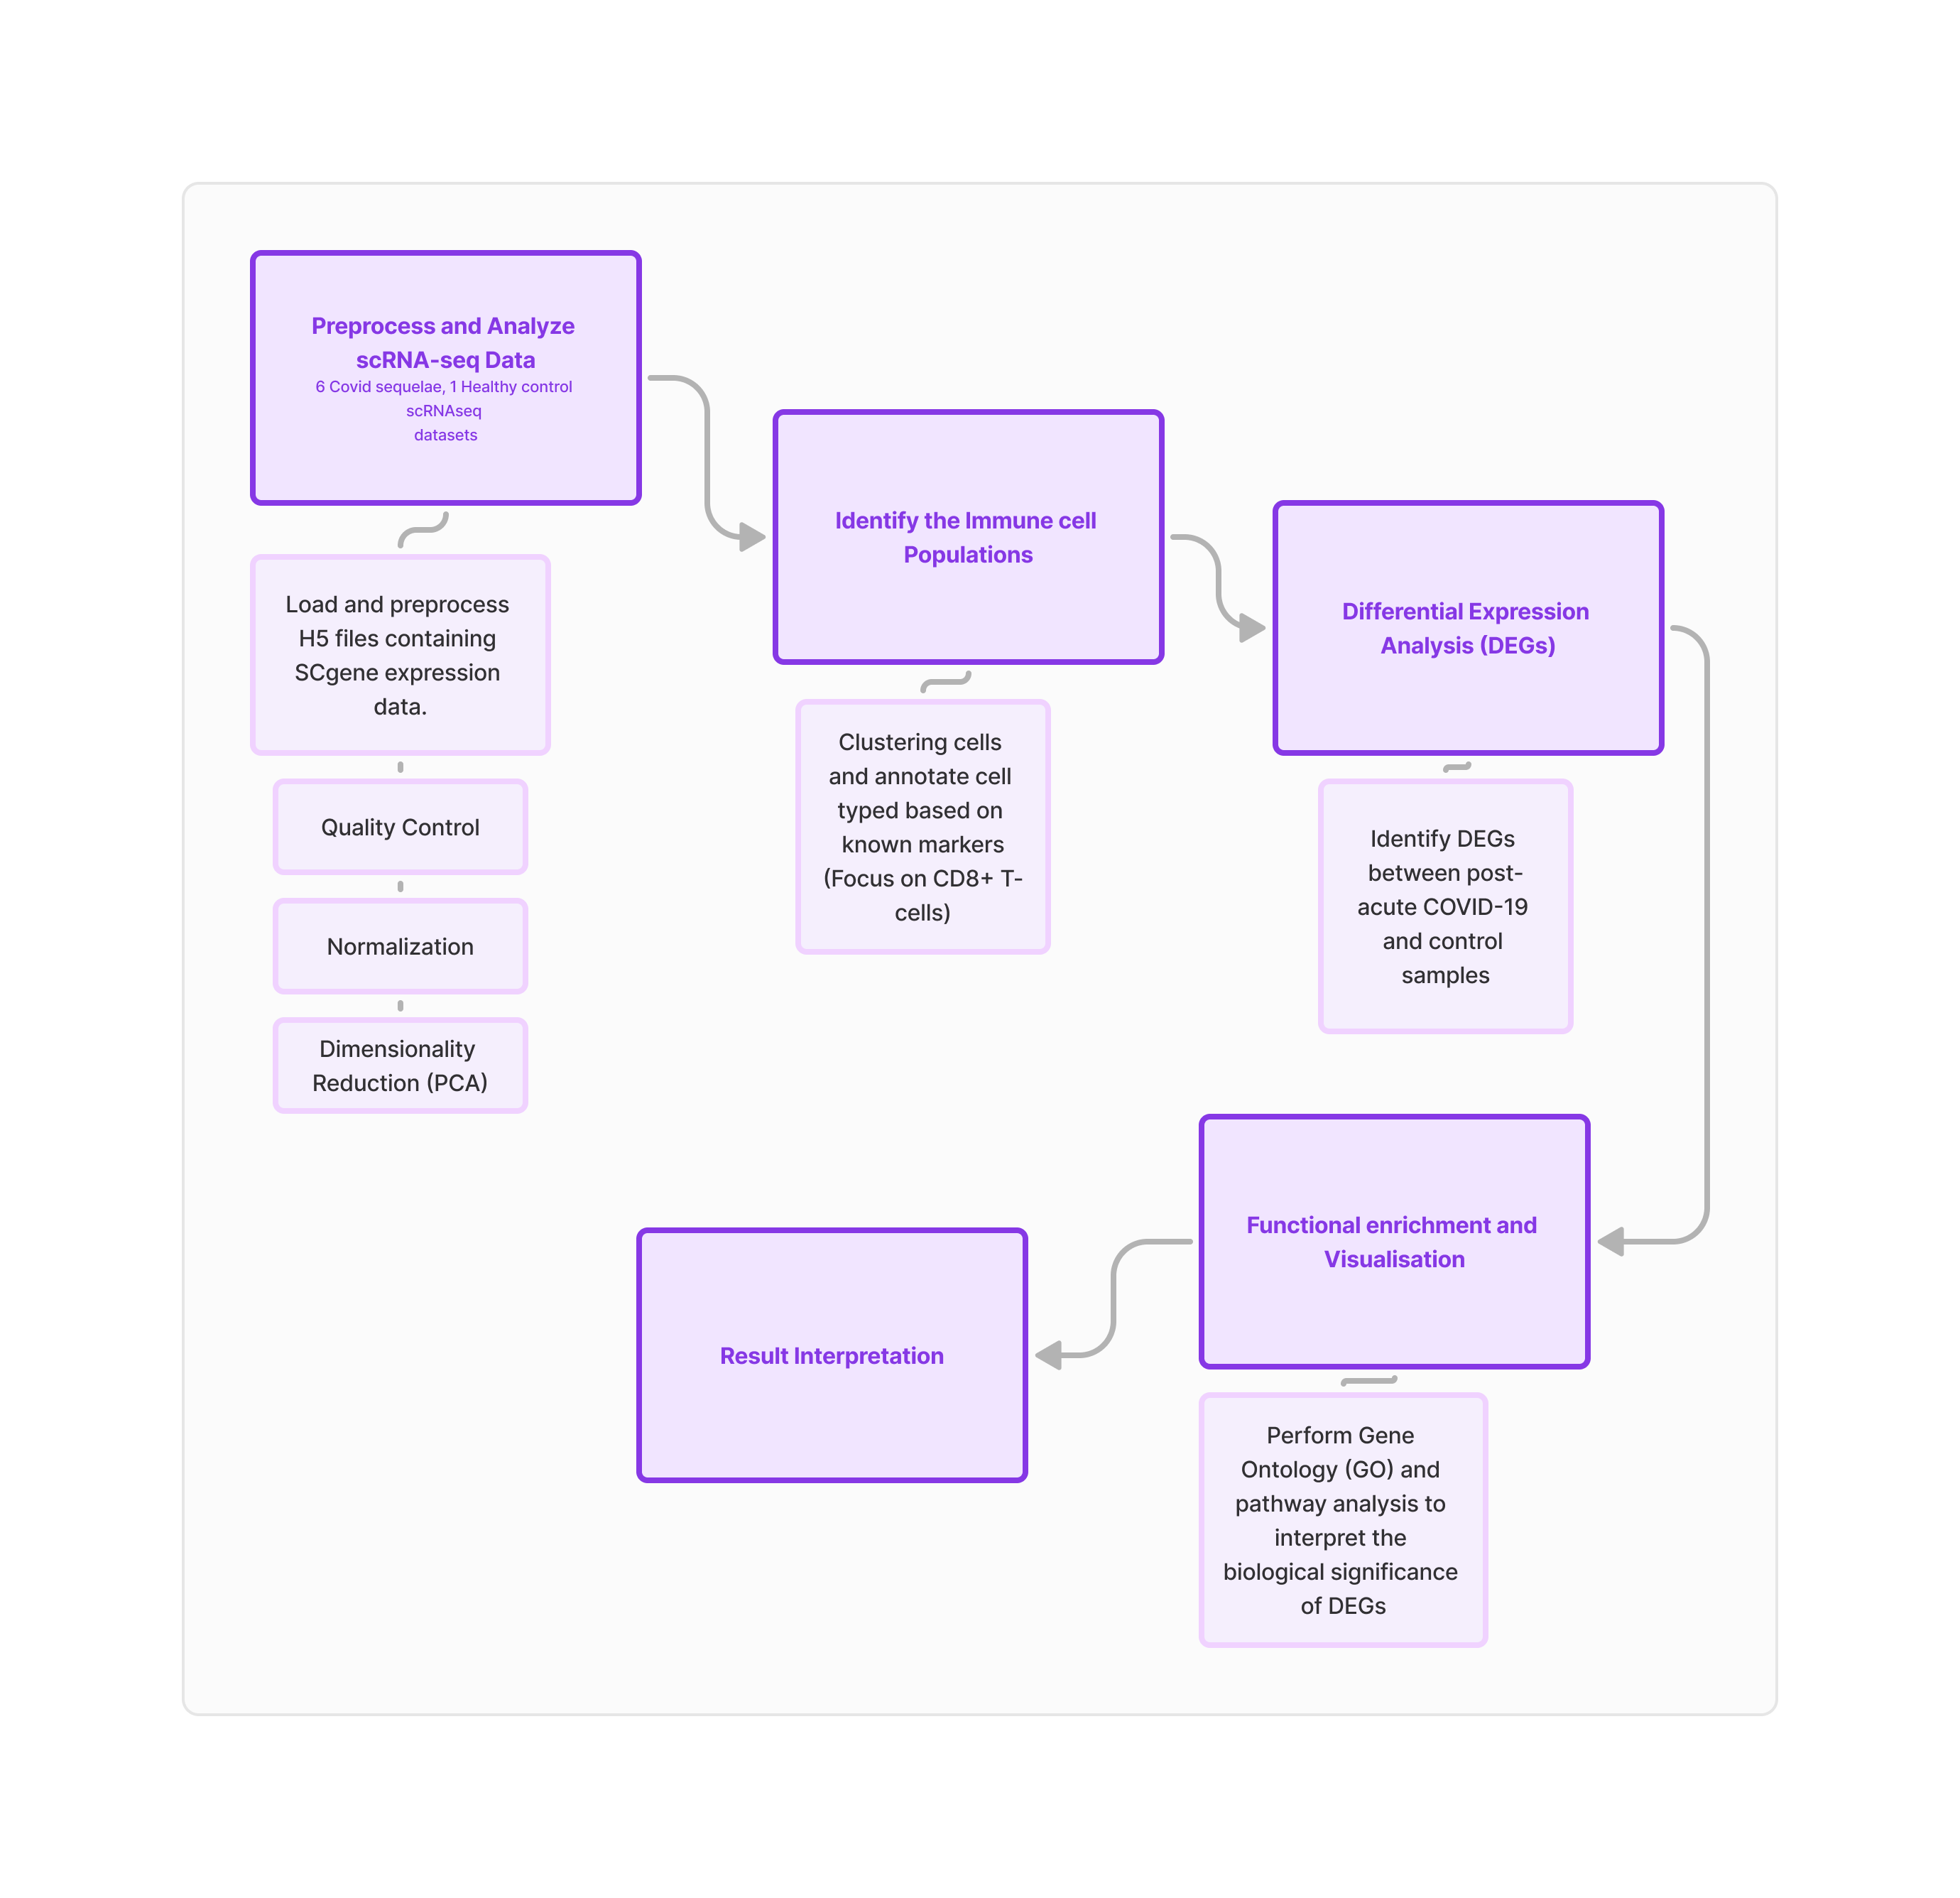


# **Primay Codebase**


## **Packages** installation and **environment setup**

In [ ]:
options(repos = "https://cloud.r-project.org/") # Set working CRAN mirror
# First install system dependencies
install.packages("BiocManager")
BiocManager::install(c("SingleCellExperiment", "limma"))
BiocManager::install("glmGamPoi")

# Then install CRAN packages
install.packages(c("tidyverse", "patchwork", "ggrepel"))

# Install Seurat from GitHub
install.packages("remotes")
remotes::install_github("satijalab/seurat", ref = "release/5.0.0")

install.packages("hdf5r")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.3 (2025-02-28)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'SingleCellExperiment' 'limma'”
Old packages: 'Seurat', 'broom', 'curl', 'foreign', 'gert', 'httr2',
  'jsonlite', 'pkgbuild', 'stringi'

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.3 (2025-02-28)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'glmGamPoi'”
Old packages: 'Seurat', 'broom', 'curl', 'foreign', 'gert', 'httr2',
  'jsonlite', 'pkgbuild', 'stringi'

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Skipping install of 'Seurat' from a github remote, the SHA1 (a4075e78) has not changed since la

In [ ]:
library(Seurat)
library(tidyverse)
library(patchwork)
library(ggplot2)

### Loading the H5 Dataset

In [ ]:
list.files("/content")

[1] "GSM5359855_GEX-CITE-rerun_20201208_CO_PBMC_BAL.filtered_feature_bc_matrix.h5"  
 [2] "GSM5359856_TCR_20201208_CO_PBMC_BAL.filtered_contig_annotations.csv"           
 [3] "GSM5359856_TCR_20201208_CO_PBMC_BAL.filtered_contig_annotations.csv.gz"        
 [4] "GSM5359857_GEX-CITE_20210119_CO_PBMC_BAL.filtered_feature_bc_matrix.h5"        
 [5] "GSM5359858_GEX-CITE_20210122_CO_PBMC_BAL_1.filtered_feature_bc_matrix.h5"      
 [6] "GSM5359859_GEX-CITE_20210122_CO_PBMC_BAL_2_rerun.filtered_feature_bc_matrix.h5"
 [7] "GSM5359860_GEX-CITE_20210201_CO2_PBMC_BAL.filtered_feature_bc_matrix.h5"       
 [8] "GSM5359861_GEX-CITE_20210203_CO_PBMC_BAL.filtered_feature_bc_matrix.h5"        
 [9] "GSM5359862_TCR_20210119_CO_PBMC_BAL.filtered_contig_annotations.csv"           
[10] "GSM5359862_TCR_20210119_CO_PBMC_BAL.filtered_contig_annotations.csv.gz"        
[11] "GSM5359863_TCR_20210122_CO_PBMC_BAL_1.filtered_contig_annotations.csv"         
[12] "GSM5359863_TCR_20210122_CO_PBMC_BAL_1.filtered_contig_annotations.csv.gz"      
[13] "GSM5359864_TCR_20210122_CO_PBMC_BAL_2.filtered_contig_annotations.csv"         
[14] "GSM5359864_TCR_20210122_CO_PBMC_BAL_2.filtered_contig_annotations.csv.gz"      
[15] "GSM5359865_TCR_20210201_CO_PBMC_BAL.filtered_contig_annotations.csv"           
[16] "GSM5359865_TCR_20210201_CO_PBMC_BAL.filtered_contig_annotations.csv.gz"        
[17] "GSM5359866_TCR_20210203_CO_PBMC_BAL.filtered_contig_annotations.csv"           
[18] "GSM5359866_TCR_20210203_CO_PBMC_BAL.filtered_contig_annotations.csv.gz"        
[19] "GSM5359867_GEX_20201201_HD_BAL_GEX.filtered_feature_bc_matrix.h5"              
[20] "GSM5359868_GEX-CITE_HD_BAL_PBMC.filtered_feature_bc_matrix.h5"                 
[21] "sample_data"

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome

Genome matrix has multiple modalities, returning a list of matrices for this genome




COVID_Recovery        Healthy 
         41469          18988 

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in gzfile(file, mode):
“cannot open compressed file '/kaggle/working/merged_seurat_object.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, mode): cannot open the connection


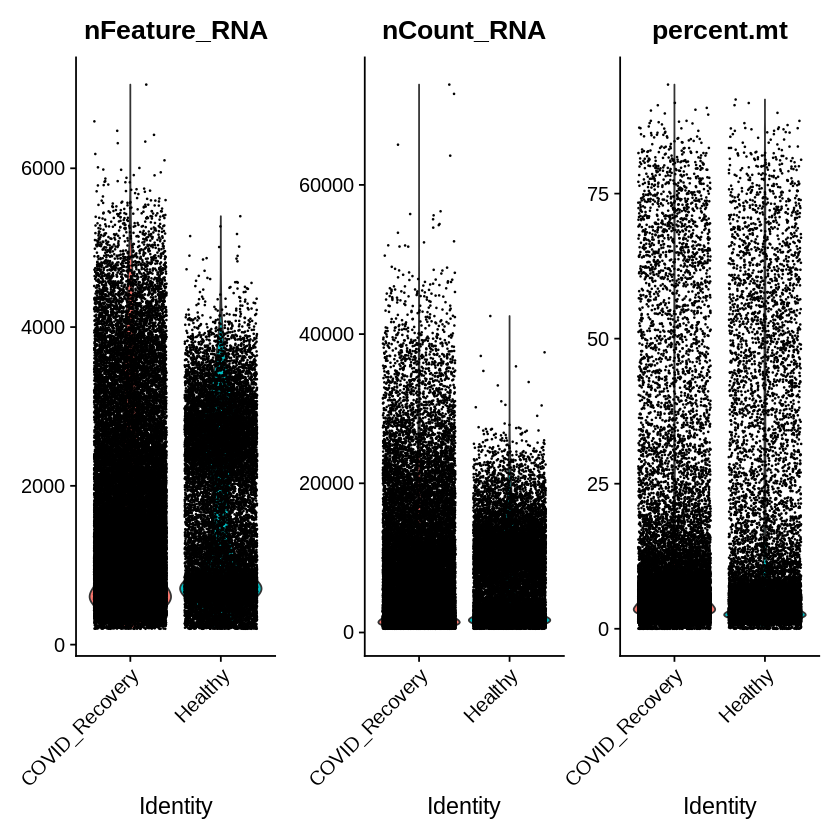

In [ ]:
# 1. Load Required Libraries
library(Seurat)
library(tidyverse)

# 2. Identify COVID vs. Healthy Files
data_files <- list.files(
  path = "/content",
  pattern = "\\.h5$",
  full.names = TRUE,
  recursive = TRUE
)

# Separate files into COVID and Healthy groups
covid_files <- data_files[grep("_CO_", data_files)]
healthy_files <- data_files[grep("_HD_", data_files)]

# 3. Fixed Data Loading Function
load_data <- function(files, project_name) {
  seurat_list <- lapply(files, function(h5_file) {
    # Load data (handle S4 class)
    data <- Read10X_h5(h5_file)

    # Extract counts (works for both plain matrices and multiome data)
    counts <- if (is.list(data)) data$`Gene Expression` else data

    # Create Seurat object
    obj <- CreateSeuratObject(
      counts = counts,
      project = project_name,
      min.cells = 3,
      min.features = 200
    )

    # Add unique sample prefix to cell names
    sample_id <- tools::file_path_sans_ext(basename(h5_file))
    obj <- RenameCells(obj, new.names = paste0(sample_id, "_", colnames(obj)))

    return(obj)
  })

  # Merge objects
  Reduce(merge, seurat_list)
}

# 4. Load Data
seurat_covid <- load_data(covid_files, "COVID_Recovery")
seurat_healthy <- load_data(healthy_files, "Healthy")

# 5. Merge and Add Metadata
seurat_merged <- merge(seurat_covid, seurat_healthy)

# Add disease_status
seurat_merged$disease_status <- ifelse(
  grepl("COVID", seurat_merged@meta.data$orig.ident),
  "COVID_Recovery",
  "Healthy"
)

# Verify groups
table(seurat_merged$disease_status)

# 6. QC and Save
seurat_merged[["percent.mt"]] <- PercentageFeatureSet(seurat_merged, pattern = "^MT-")
VlnPlot(seurat_merged,
        features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
        group.by = "disease_status",
        pt.size = 0.1)
saveRDS(seurat_merged, "/kaggle/working/merged_seurat_object.rds")

## **Preprocessing** of the data (**H5 files** i.e. scRNA data analysis)

### → **Quality control** of the data
Generally, it primarily involves following checks in the pararmetres (for Seurat):

| **Parameter** | **Description** | **Typical Threshold** |
| --- | --- | --- |
| `nFeature_RNA` | Number of genes detected per cell | > 500--1,000 |
| `nCount_RNA` | Total counts (UMIs) per cell | > 500--1,000 |
| `percent.mt` | Percentage of mitochondrial genes | < 5--20% |
| `percent.ribo` | Percentage of ribosomal genes | Varies (often used as a secondary metric) |
| `Doublet Score` | Likelihood of a cell being a doublet | < 0.25 |
| `Genes Detected in Cells` | Number of cells expressing a gene | > 10 |
| `Average Gene Expression` | Average expression level of a gene across cells | > 0.1--0.5 |

Calculating the following parameters:
- Mitochondrial gene percentage
- Number of detected genes per cell
- Total counts per cell

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


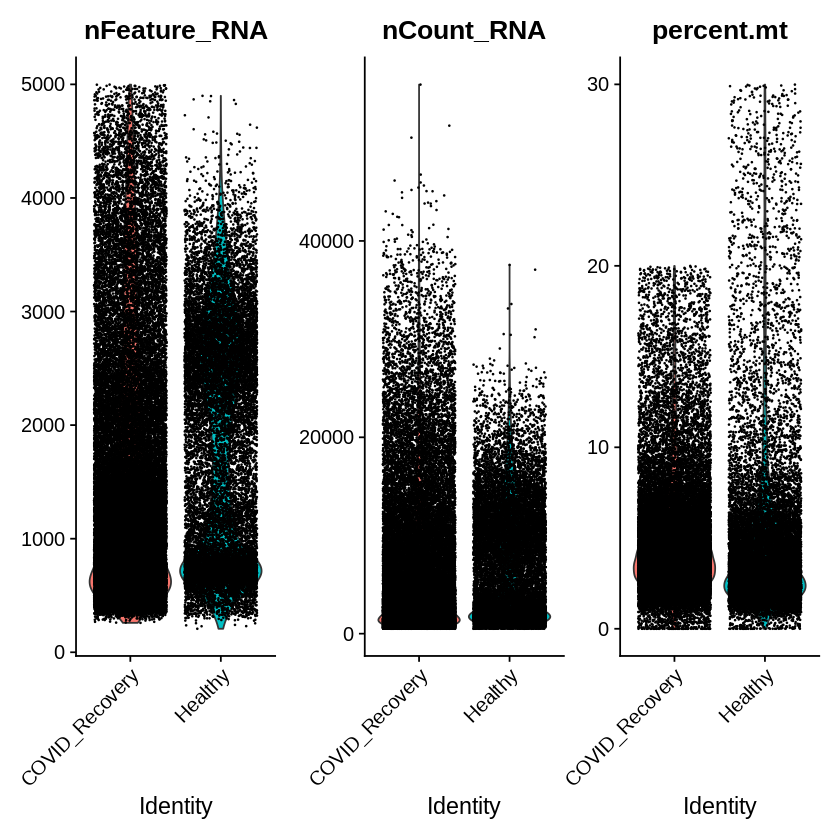

In [ ]:
# Define QC thresholds for each group
seurat_filtered <- subset(
  seurat_merged,
  subset = (disease_status == "Healthy" &
             nFeature_RNA > 50 &        # Relaxed for Healthy
             nFeature_RNA < 5000 &
             percent.mt < 30) |
           (disease_status == "COVID_Recovery" &
             nFeature_RNA > 200 &       # Stricter for COVID
             nFeature_RNA < 5000 &
             percent.mt < 20)
)

# Visualize post-filtering QC metrics BY GROUP
VlnPlot(seurat_filtered,
        features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
        group.by = "disease_status",
        pt.size = 0.1,
        ncol = 3) +
  NoLegend()

# Save filtered data
saveRDS(seurat_filtered, "seurat_filtered.rds")

Visualize the QC metrics to decide on filtering thresholds.



Here, we choose to consider these parametres to go for filtering data in Quality control:
1. Cells with **high mitochondrial gene** percentages on account for cell dying or apopotosis stage cell have high mitochondiral counts. (e.g., >20%).
2. Cells with extremely **high numbers of detected genes** on account for Doublets (e.g., >2,500).
3. Cells with extremely **low numbers of detected genes** on account for low quality of cell or wrong detection of cell when it is not present at all (e.g., <200).


### → **Normalisation** of the data

Choosing Perfect **NORMALISATION Method**

- Given the high variance and right skew, methods that account for overdispersion would be better. Hence, **deviating** from Author's **Log Transformation** to this because total count normalization (like CPM) followed by log transformation is a common approach, but when the data is very skewed, methods like SCTransform or Pearson Residuals are more robust as they model the count distribution more accurately.

- The presence of a high max value (45k) compared to the median suggests that some cells have much higher counts. Using methods that regularize the variance or stabilize it (like SCTransform) would mitigate the effect of these outliers. Also, since the data is single-cell, it's typical to use methods designed for sparse UMI data.

- So, the best normalization methods here would likely be **SCTransform** or **Pearson Residuals**. By removing this technical variance, we hope to decrease our Type-1 Error (False Positives), hopefully resulting in a shorter list of DE genes later in our pipeline.

**SCTransform Normalisation**

In [ ]:
# Split the Seurat object by sample identity
# This creates a list, with each element being a Seurat object for one sample.
seurat_list <- SplitObject(seurat_filtered, split.by = "orig.ident")

# Normalize each sample individually using SCTransform
# We loop through the list to apply normalization to each object.
for (i in 1:length(seurat_list)) {
    seurat_list[[i]] <- SCTransform(seurat_list[[i]], verbose = FALSE)
}


Will not return corrected UMI because residual type is not set to 'pearson'

Will not return corrected UMI because residual type is not set to 'pearson'

Will not return corrected UMI because residual type is not set to 'pearson'

Will not return corrected UMI because residual type is not set to 'pearson'

Will not return corrected UMI because residual type is not set to 'pearson'



**Integration**

- After normalization, the different datasets were integrated using Seurat’s `FindIntegrationAnchors()` and `IntegrateData()` functions.
- The Seurat integration method
jointly reduces the dimensionality of all datasets using diagonalized CCA, then apply L2-normalization to the canonical correlation vectors.
- Then the method searches for MNNs (Mutual Nearest Neighbors, represent two cells that are expected to share a common set of molecular features.) in this shared low-dimensional representation.
- The resulting cell pairs are referred to as “anchors,” and are used as the basis for integrating the datasets.
- These integration procedures help reduce the confounding batch effect between datasets and samples while retaining the biological differences of interest.

In [ ]:
# Selects the most variable features to guide the integration.
# Then, prepare the list of objects for finding anchors.
integration_features <- SelectIntegrationFeatures(object.list = seurat_list, nfeatures = 3000)
seurat_list <- PrepSCTIntegration(object.list = seurat_list, anchor.features = integration_features, verbose = FALSE)

# Find integration anchors.
# This step identifies the corresponding cells (anchors) across the different samples.
integration_anchors <- FindIntegrationAnchors(object.list = seurat_list, normalization.method = "SCT", anchor.features = integration_features, verbose = FALSE)

# Integrate the datasets.
# This creates a new, integrated Seurat object with batch effects corrected.
seurat_integrated <- IntegrateData(anchorset = integration_anchors, normalization.method = "SCT", verbose = FALSE)


### → **PCA** & **Clustering** *italicized text*

- Once the data was successfully integrated, we reduced the dimensionality of the dataset via principal component analysis (PCA).
- To determine the **“dimensionality”** of the dataset, we ploed the variance explained by each principal component in an elbow plot.
- Using this elbow plot, we chose to use the first 10 PCs in our downstream analysis. Using these 10
PCs, we clustered the data using Seurat’s `FindNeighbors()` and `FindClusters()` functions.
- `FindNeighbors()` utilizes a K-nearest neighbors (KNN) grouping method, using by default 20 kparameters, which means that it finds a cell’s 20 K-nearest neighbors based on their scaled
similarities in the 1st 10 PCs (set by us).
-  `FindClusters()` identifies clusters of cells by a shared nearest
neighbor (SNN) modularity optimization-based clustering algorithm. It uses the k-nearest neighbors to construct the SNN graph, then optimizes the modularity function to determine clusters.

**PCA**

In [ ]:
# 1. Run PCA on the integrated data
# This step reduces the dimensionality of your dataset.
seurat_integrated <- RunPCA(seurat_integrated, verbose = FALSE)

# 2. Create an Elbow Plot
# This plot is for visualising the variance explained by each principal component to choose the optimal number of dimensions for clustering.
ElbowPlot(seurat_integrated)

**Clustering**

In [ ]:
# Cluster the cells using the principal components
seurat_integrated <- FindNeighbors(seurat_integrated, reduction = "pca", dims = 1:10)
seurat_integrated <- FindClusters(seurat_integrated, resolution = 0.5)

# To view the clustering results, for example by using DimPlot.
head(seurat_integrated@meta.data)

### → Find **Gene Markers** and **Visualisation**

- Using **Seurat-determined clusters** or disease status as grouping parameters, we then used Seurat’s
`FindAllMarkers()` to determine the differentially expressed genes (DEGs) in each group.
- By default,
`FindAllMarkers()` utilizes the ***Wilcoxon rank sum test*** as the default differential expression test. The
analysis outputs an unadjusted p-value and an adjusted p-value that is based
on Bonferroni correction using all genes in the dataset.

> The Bonferroni adjustment is stringent and minimizes false positives.

- The published results utilized ***MAST test*** for the differential expression
that considers the zero-inflated nature of single-cell expression matrices by treating gene detection
as a covariate and then applying the Bonferroni correction.
- Once we had a list of DEGs, we ranked
them by the **log2-fold** change of the average expression between groups.
- The top-ranked DEGs were
then visualized on a heat map.
- In addition to determining
DEGs, we embedded the cells on a UMAP plot and colored them based on
either their healthy or diseased status, or their Seurat-determined clusters.
- UMAP constructs a high-dimensional graph representation of the data
then optimizes a low-dimensional graph to be as structurally similar as possible. It’s similar to t-SNE
but runs much faster.



**Heatmap** and **UMAP**

In [ ]:
# Plot 1: UMAP grouped by disease status
# This visualizes the biological difference between the healthy and diseased groups.
DimPlot(seurat_integrated, reduction = "umap", group.by = "disease_status")

# 1. Heatmap for Top 10 DEGs by Disease Status
# Find the markers between 'Diseased' and 'Healthy' status.
disease_markers <- FindMarkers(seurat_integrated, ident.1 = "COVID_Recovery", ident.2 = "Healthy", group.by = "disease_status")

# Get the top 10 DEGs.
top10_disease_degs <- rownames(head(disease_markers, 10))

# Create the heatmap.
DoHeatmap(seurat_integrated, features = top10_disease_degs, group.by = "disease_status")

In [ ]:
# Plot 2: UMAP grouped by Seurat-determined clusters
# This visualizes the different cell clusters found by the algorithm.
DimPlot(seurat_integrated, reduction = "umap", label = TRUE)

# 2. Heatmap for Top 5 DEGs by Seurat Cluster

# Find the top 5 markers for EACH cluster compared to all other clusters.
library(dplyr)
cluster_markers <- FindAllMarkers(seurat_integrated, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25)
top5_cluster_degs <- cluster_markers %>%
    group_by(cluster) %>%
    top_n(n = 5, wt = avg_log2FC)

# Create the heatmap.
DoHeatmap(seurat_integrated, features = top5_cluster_degs$gene)